# SQLStorm TPC-H — identical and similar queries

The TPC-H counterpart of `sqlstorm_outputs.ipynb`. No output run exists for TPC-H yet, so this notebook
only compares the **SQL text** of the 17,036 queries in `cache/sqlstorm_cache/queries/` (pulled by
`sqlstorm_analysis.ipynb`), with the same method as the StackOverflow export:

* **identical** — equal after normalisation (SQLStorm header comment and `EXPLAIN (…)` wrapper removed,
  comments removed, whitespace collapsed, lower-cased);
* **similar** — different text with token 3-gram Jaccard similarity ≥ 0.8 (MinHash LSH for candidates,
  exact Jaccard to confirm).

Outputs (`csv/`):

| file | content |
|---|---|
| `sqlstorm_tpch_duplicates_and_similar.csv` | one row per query with an identical or similar query: the other queries, as lists |
| `sqlstorm_tpch_duplicate_and_similar_groups.csv` | one row per group of queries joined by these relations |
| `sqlstorm_tpch_sqlglot.csv` | per query: sqlglot canonical form, template and structural similarity (§5) |

§5 repeats the comparison on parsed syntax trees (sqlglot); §6 is where the output comparison will go once an
output run is done.

In [1]:
import re, zlib, hashlib, itertools, collections, difflib, time
from pathlib import Path
import numpy as np
import pandas as pd

QDIR = Path("cache/sqlstorm_cache/queries")
EXPECT = 17036
J_MIN = 0.8                       # similarity threshold (token 3-gram Jaccard)
NP_, BANDS, ROWS = 128, 16, 8     # MinHash signature length, LSH bands x rows
SEED = 20261004

FILES = sorted(QDIR.glob("*.sql"), key=lambda p: int(p.stem))
assert len(FILES) == EXPECT, f"{len(FILES)} query files in {QDIR}, expected {EXPECT} — run sqlstorm_analysis.ipynb first"
SQL_RAW = {int(f.stem): f.read_text("utf-8", "replace") for f in FILES}
HEAD = re.search(r"SQLStorm (v[\d.]+)/(\S+?)/queries/\S+ @ (\w+)", SQL_RAW[int(FILES[0].stem)].splitlines()[0])
print(f"{len(SQL_RAW)} queries from SQLStorm {HEAD.group(1)} {HEAD.group(2)} (commit {HEAD.group(3)})")

17036 queries from SQLStorm v1.0 tpch (commit b3bb0b96)


## 1. Identical SQL

How many distinct texts remain as each normalisation step is added, then the copy sets at the full
normalisation.

In [2]:
def strip_wrapper(t):
    return "\n".join(l for l in t.split("\n") if not l.startswith("-- SQLStorm"))


def norm_sql(t, lower=True, ws=True):
    s = re.sub(r"--[^\n]*", " ", t)
    s = re.sub(r"/\*.*?\*/", " ", s, flags=re.S)
    s = re.sub(r"(?is)^\s*EXPLAIN\s*\([^)]*\)", " ", s)
    if ws:
        s = re.sub(r"\s+", " ", s).strip().rstrip(";").strip()
    return s.lower() if lower else s


LEVELS = pd.Series({
    "only the header line": len({strip_wrapper(t) for t in SQL_RAW.values()}),
    "+ whitespace and comments": len({norm_sql(t, lower=False) for t in SQL_RAW.values()}),
    "+ upper/lower case": len({norm_sql(t) for t in SQL_RAW.values()}),
}, name="distinct texts")
SQLN = pd.Series({q: norm_sql(t) for q, t in SQL_RAW.items()})
SQLH = SQLN.map(lambda s: hashlib.md5(s.encode()).hexdigest())
CANON = SQLN.map(SQLN.reset_index().groupby(0)["index"].min())       # query -> lowest query with the same text
U = np.sort(CANON.unique())
DUPN = CANON.map(CANON.value_counts())
print(LEVELS.to_string())
print(f"\ncopy sets: {int((CANON.value_counts() > 1).sum())}, holding {int((DUPN > 1).sum())} queries "
      f"({len(SQLN) - len(U)} more than distinct texts); largest set {DUPN.max()}")

only the header line         17002
+ whitespace and comments    15695
+ upper/lower case           15573

copy sets: 707, holding 2170 queries (1463 more than distinct texts); largest set 16


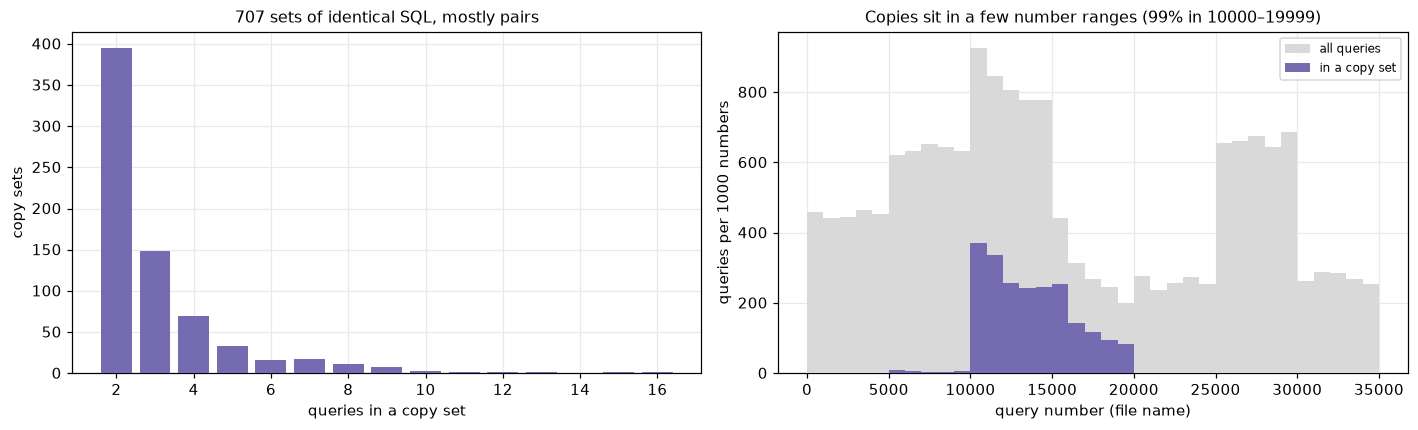

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
                     "axes.grid": True, "grid.color": "#e9e9e9", "axes.axisbelow": True,
                     "font.size": 9.5, "figure.dpi": 110})
FIG = Path("figures/sqlstorm_outputs_tpch"); FIG.mkdir(parents=True, exist_ok=True)


def savefig(fig, name):
    fig.savefig(FIG / f"{name}.svg", bbox_inches="tight")


fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
sz = CANON.value_counts()
sz = sz[sz > 1].value_counts().sort_index()
ax.bar(sz.index, sz, color="#756bb1", zorder=3)
ax.set_xlabel("queries in a copy set"); ax.set_ylabel("copy sets")
ax.set_title(f"{int(sz.sum())} sets of identical SQL, mostly pairs", fontsize=10.5)
ax = axes[1]
bins = np.arange(0, max(SQLN.index) + 1000, 1000)
ax.hist(SQLN.index, bins=bins, color="#d9d9d9", label="all queries", zorder=3)
ax.hist(SQLN.index[DUPN > 1], bins=bins, color="#756bb1", label="in a copy set", zorder=3)
ax.set_xlabel("query number (file name)"); ax.set_ylabel("queries per 1000 numbers"); ax.legend(fontsize=8)
blk = (DUPN > 1).groupby((SQLN.index // 5000) * 5000).sum()
ax.set_title(f"Copies sit in a few number ranges ({100 * blk.loc[[10000, 15000]].sum() / blk.sum():.0f}% in 10000–19999)",
             fontsize=10.5)
fig.tight_layout(); savefig(fig, "identical_sql"); plt.show()

## 2. Similar SQL

Each distinct text is split into tokens (words and single symbols) and turned into the set of its
overlapping 3-token runs. Two texts are **similar** when the Jaccard index of these sets is ≥ 0.8.
Comparing all ~121 million pairs directly is slow, so MinHash LSH proposes candidates: a 128-value
signature per text, cut into 16 bands of 8; texts sharing any band are candidates, and their exact
Jaccard decides. A pair at exactly 0.8 is found with probability ≈ 95 %, at 0.9 with > 99.9 %.

15573 distinct texts -> 111652 candidate pairs -> 18916 similar pairs (Jaccard >= 0.8) between 3155 texts  [3 s]


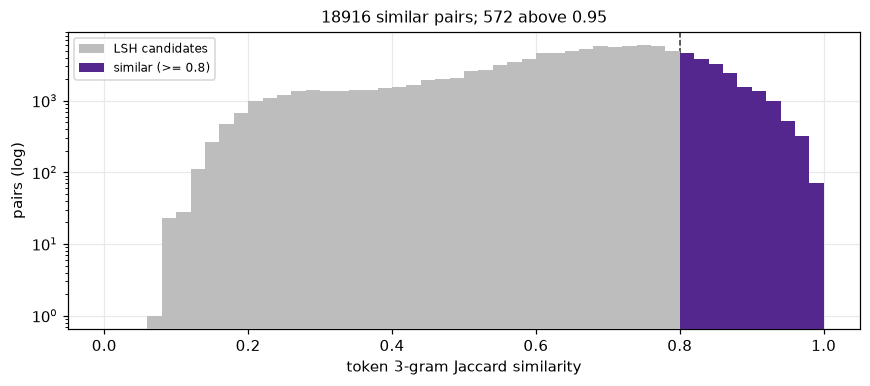

In [4]:
t0 = time.time()
toks = {q: re.findall(r"\w+|[^\w\s]", SQLN[q]) for q in U}
SH = {q: {zlib.crc32(" ".join(t[i:i + 3]).encode()) for i in range(max(1, len(t) - 2))} for q, t in toks.items()}
rng = np.random.default_rng(SEED)
A_ = rng.integers(1, 2 ** 63, NP_, dtype=np.uint64) | np.uint64(1)
B_ = rng.integers(0, 2 ** 63, NP_, dtype=np.uint64)
SIG = {q: ((np.fromiter(s, np.uint64)[:, None] * A_ + B_) >> np.uint64(16)).min(axis=0) for q, s in SH.items()}
cand = set()
for bnd in range(BANDS):
    buckets = collections.defaultdict(list)
    for q, v in SIG.items():
        buckets[v[bnd * ROWS:(bnd + 1) * ROWS].tobytes()].append(q)
    for qs in buckets.values():
        cand.update(itertools.combinations(sorted(qs), 2))
PAIRS = pd.DataFrame([(a, c, len(SH[a] & SH[c]) / len(SH[a] | SH[c])) for a, c in cand], columns=["a", "b", "jaccard"])
P_FOUND = 1 - (1 - J_MIN ** ROWS) ** BANDS
NEAR = PAIRS[PAIRS["jaccard"] >= J_MIN].sort_values(["a", "b"]).reset_index(drop=True)
print(f"{len(U)} distinct texts -> {len(cand)} candidate pairs -> {len(NEAR)} similar pairs (Jaccard >= {J_MIN}) "
      f"between {NEAR[['a', 'b']].stack().nunique()} texts  [{time.time() - t0:.0f} s]")

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(PAIRS["jaccard"], bins=np.linspace(0, 1, 51), color="#bdbdbd", label="LSH candidates", zorder=3)
ax.hist(NEAR["jaccard"], bins=np.linspace(0, 1, 51), color="#54278f", label=f"similar (>= {J_MIN})", zorder=3)
ax.axvline(J_MIN, color="#333", ls="--", lw=1)
ax.set_yscale("log"); ax.set_xlabel("token 3-gram Jaccard similarity"); ax.set_ylabel("pairs (log)"); ax.legend(fontsize=8)
ax.set_title(f"{len(NEAR)} similar pairs; {int((NEAR['jaccard'] >= 0.95).sum())} above 0.95", fontsize=10.5)
fig.tight_layout(); savefig(fig, "similarity"); plt.show()

## 3. Groups

A group is every query reachable through identical or similar links (connected components). Similar
links chain: A~B and B~C put A and C in one group even when A and C are less alike, so each group also
reports how much of it is directly linked (`linked_share`: similar pairs found / pairs of distinct texts)
and the lowest and highest similarity of its links. In `queries`, `=` joins identical SQL and `|`
separates different texts — the same layout as the StackOverflow groups file.

341 groups covering 4653 queries:
                    groups  queries  largest
kind                                        
copies + similar       112     3995      816
identical (copies)      35       86        7
similar                194      572       14


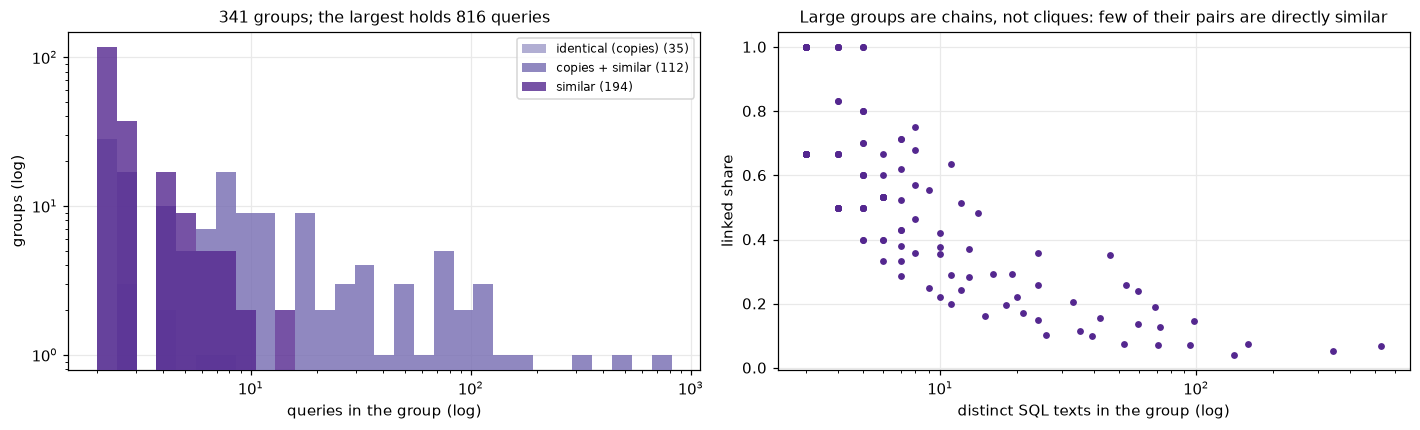

In [5]:
class DSU:
    def __init__(self, nodes):
        self.p = {n: n for n in nodes}

    def find(self, x):
        while self.p[x] != x:
            self.p[x] = self.p[self.p[x]]; x = self.p[x]
        return x

    def union(self, a, c):
        self.p[self.find(a)] = self.find(c)


dsu = DSU(U)
for a, c in NEAR[["a", "b"]].itertuples(index=False):
    dsu.union(a, c)
root = pd.Series({q: dsu.find(q) for q in U})
COMP = CANON.map(root)                                                 # query -> component root
members = CANON.reset_index().groupby(0)["index"].apply(sorted)      # canonical text -> its queries
edges = NEAR.assign(comp=NEAR["a"].map(root))

rows = []
for r, qs in COMP.groupby(COMP).groups.items():
    qs = sorted(qs)
    texts = sorted({CANON[q] for q in qs})
    if len(qs) < 2:
        continue
    e = edges[edges["comp"] == r]
    n_t = len(texts)
    rows.append(dict(
        n_queries=len(qs), n_sql=n_t,
        kind="identical (copies)" if n_t == 1 else ("similar" if n_t == len(qs) else "copies + similar"),
        sim_min=round(e["jaccard"].min(), 4) if len(e) else np.nan,
        sim_max=round(e["jaccard"].max(), 4) if len(e) else np.nan,
        linked_share=round(len(e) / (n_t * (n_t - 1) / 2), 3) if n_t > 1 else np.nan,
        queries=" | ".join(" = ".join(map(str, members[t])) for t in texts),
        first=qs[0]))
GROUPS = pd.DataFrame(rows).sort_values(["n_queries", "first"], ascending=[False, True]).drop(columns="first")
GROUPS.insert(0, "group", [f"G{i + 1}" for i in range(len(GROUPS))])
GID = {int(q): g for g, qq in zip(GROUPS["group"], GROUPS["queries"]) for q in re.findall(r"\d+", qq)}
print(f"{len(GROUPS)} groups covering {GROUPS['n_queries'].sum()} queries:")
print(GROUPS.groupby("kind").agg(groups=("group", "size"), queries=("n_queries", "sum"),
                                 largest=("n_queries", "max")).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
for k, col in [("identical (copies)", "#9e9ac8"), ("copies + similar", "#756bb1"), ("similar", "#54278f")]:
    s = GROUPS.loc[GROUPS["kind"] == k, "n_queries"]
    ax.hist(s, bins=np.logspace(np.log10(2), np.log10(GROUPS["n_queries"].max() + 1), 30), color=col, alpha=0.8,
            label=f"{k} ({len(s)})", zorder=3)
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlabel("queries in the group (log)"); ax.set_ylabel("groups (log)")
ax.legend(fontsize=8)
ax.set_title(f"{len(GROUPS)} groups; the largest holds {GROUPS['n_queries'].max()} queries", fontsize=10.5)
ax = axes[1]
g = GROUPS[GROUPS["n_sql"] > 2]
ax.scatter(g["n_sql"], g["linked_share"], s=12, color="#54278f", zorder=3)
ax.set_xscale("log"); ax.set_xlabel("distinct SQL texts in the group (log)"); ax.set_ylabel("linked share")
ax.set_title("Large groups are chains, not cliques: few of their pairs are directly similar", fontsize=10.5)
fig.tight_layout(); savefig(fig, "groups"); plt.show()

## 4. Per-query lists and export

Per query, the other queries in each relation (`;`-separated, symmetric) and their counts, plus the
group id. Then two helpers for looking at the queries directly: `show_group("G12")` prints the distinct
SQL texts of a group, `sql_diff(q1, q2)` diffs two queries.

In [6]:
nbr = collections.defaultdict(set)
for a, c in NEAR[["a", "b"]].itertuples(index=False):
    nbr[a].update(members[c]); nbr[c].update(members[a])
best = pd.concat([NEAR, NEAR.rename(columns={"a": "b", "b": "a"})]).sort_values("jaccard", ascending=False)
best = best.drop_duplicates("a").set_index("a")
dup_others = CANON.reset_index().groupby(0)["index"].apply(sorted)

DS = pd.DataFrame(index=pd.Index(SQLN.index, name="query"))
DS["sql_hash"] = SQLH
DS["duplicate_queries"] = [";".join(str(x) for x in dup_others[CANON[q]] if x != q) or pd.NA for q in DS.index]
DS["duplicate_count"] = (DUPN - 1).where(DUPN > 1).astype("Int64")
DS["similar_queries"] = [";".join(map(str, sorted(nbr[CANON[q]]))) if CANON[q] in nbr else pd.NA for q in DS.index]
DS["similar_count"] = pd.Series({q: len(nbr[CANON[q]]) for q in DS.index if CANON[q] in nbr}).reindex(DS.index).astype("Int64")
DS["most_similar_query"] = CANON.map(best["b"]).astype("Int64")
DS["most_similar_jaccard"] = CANON.map(best["jaccard"]).round(3)
DS["group"] = DS.index.map(GID)
OUT = DS[DS["duplicate_count"].notna() | DS["similar_count"].notna()]
OUT.to_csv("csv/sqlstorm_tpch_duplicates_and_similar.csv")
GROUPS.to_csv("csv/sqlstorm_tpch_duplicate_and_similar_groups.csv", index=False)
print(f"csv/sqlstorm_tpch_duplicates_and_similar.csv: {len(OUT)} queries "
      f"({int(OUT['duplicate_count'].notna().sum())} with a duplicate, {int(OUT['similar_count'].notna().sum())} with a similar query)")
print(f"csv/sqlstorm_tpch_duplicate_and_similar_groups.csv: {len(GROUPS)} groups")


def body_sql(q):
    return "\n".join(l for l in SQL_RAW[q].split("\n")
                     if not l.startswith("-- SQLStorm") and not l.upper().startswith("EXPLAIN (")).strip()


def show_group(g, max_texts=5):
    r = GROUPS.set_index("group").loc[g]
    print(f"{g}: {r.n_queries} queries, {r.n_sql} distinct SQL, {r.kind}\n  {r.queries[:600]}\n")
    for t in sorted({CANON[int(q)] for q in re.findall(r"\d+", r.queries)})[:max_texts]:
        print(f"-- {t}\n{body_sql(t)}\n")


def sql_diff(q1, q2, context=1, max_lines=60):
    d = list(difflib.unified_diff(body_sql(q1).split("\n"), body_sql(q2).split("\n"), f"{q1}.sql", f"{q2}.sql",
                                  n=context, lineterm=""))
    print("\n".join(d[:max_lines]) + (f"\n… {len(d) - max_lines} more lines" if len(d) > max_lines else ""))


ex = NEAR[(NEAR["jaccard"] >= 0.8) & (NEAR["jaccard"] < 0.82)].iloc[0]
print(f"\nexample similar pair at the threshold: {int(ex.a)} vs {int(ex.b)} (Jaccard {ex.jaccard:.3f})")
sql_diff(int(ex.a), int(ex.b), max_lines=40)

csv/sqlstorm_tpch_duplicates_and_similar.csv: 4653 queries (2170 with a duplicate, 4567 with a similar query)
csv/sqlstorm_tpch_duplicate_and_similar_groups.csv: 341 groups

example similar pair at the threshold: 2654 vs 4390 (Jaccard 0.808)
--- 2654.sql
+++ 4390.sql
@@ -15,4 +15,4 @@
     WHERE 
-        o.o_orderdate >= DATE '1997-01-01' 
-        AND o.o_orderdate < DATE '1997-12-31'
+        o.o_orderdate >= DATE '1996-01-01' AND o.o_orderdate < DATE '1997-01-01'
+        AND l.l_returnflag = 'N'
     GROUP BY 
@@ -34,2 +34,3 @@
     r.r_name,
+    rs.s_suppkey,
     rs.s_name,
@@ -37,6 +38,3 @@
     COALESCE(rs.order_count, 0) AS order_count,
-    CASE 
-        WHEN rs.sales_rank <= 10 THEN 'Top Supplier'
-        ELSE 'Regular Supplier'
-    END AS supplier_category
+    CASE WHEN rs.sales_rank <= 10 THEN 'Top Supplier' ELSE 'Regular Supplier' END AS supplier_category
 FROM 
@@ -48,7 +46,6 @@
 LEFT JOIN 
-    RankedSuppliers rs ON c.c_custkey = rs.s_suppkey
+    RankedSuppliers 

## 5. Structure instead of tokens (sqlglot)

The token method compares SQL text. **sqlglot** parses each query into a syntax tree (PostgreSQL dialect), which
allows three sharper comparisons:

* **canonical** — identifiers lower-cased, CTE names, table aliases and the outer query's output-column aliases
  renamed by order of appearance (`cte1`, `t1`, `c1`), comments dropped. Two queries with the same canonical
  form are the same query written with other names. String literals keep their case: `'EUROPE'` and `'Europe'` are
  different filters.
* **template** — the canonical form with every literal masked (numbers, strings, dates, interval amounts, LIMIT
  values): the same query shape with other constants.
* **structure similarity** — each query becomes the set of its root-ward paths of up to 3 syntax nodes (e.g.
  `Where>GTE>Column:o_orderdate`), without aliases or literal values; pairs with Jaccard ≥ 0.8 are similar (MinHash
  LSH for candidates, exact Jaccard to confirm). Reordered joins or renamed aliases do not lower it; a change of
  which tables, columns or operators are used does. Similar queries joined together form **structural families**.

Energy below is each query's single measured copy in the SQLStorm run (warm, 2.5 GHz), so it includes the ~0.5 J
fixed cost of a batch.

In [7]:
SG_CSV = "csv/sqlstorm_tpch_sqlglot.csv"
SG_TIMING = "cache/sqlstorm_cache/logs/query_timing_tpch_idx.csv"
# %pip install sqlglot
import re, time, hashlib, zlib, itertools, collections, difflib, logging
import numpy as np
import pandas as pd
import sqlglot
from sqlglot import exp
from sqlglot.optimizer.normalize_identifiers import normalize_identifiers

logging.getLogger("sqlglot").setLevel(logging.ERROR)
SG_J_MIN, SG_DEPTH = 0.8, 3


def sg_body(t):
    s = re.sub(r"(?m)^-- SQLStorm.*$", "", t)
    return re.sub(r"(?is)^\s*EXPLAIN\s*\([^)]*\)", "", s.strip()).strip()


def sg_parse(t):
    """every statement of a query file (header and EXPLAIN wrapper removed), comments dropped"""
    trees = [x for x in sqlglot.parse(sg_body(t), read="postgres") if x is not None and not isinstance(x, exp.Semicolon)]
    for x in trees:
        for n in x.walk():
            n.comments = None
    return trees


def sg_canonical(tree):
    """lower-cased identifiers; CTE names, table/subquery aliases and the outer query's output-column aliases renamed
    by order of appearance (cte1, t1, c1); string literals keep their case"""
    t = normalize_identifiers(tree.copy(), dialect="postgres")
    ren, ta = {}, {}
    for cte in t.find_all(exp.CTE):
        ren.setdefault(cte.alias_or_name, f"cte{len(ren) + 1}")
    for al in t.find_all(exp.TableAlias):
        if al.name and al.name not in ren:
            ta.setdefault(al.name, f"t{len(ta) + 1}")
    for n in list(t.walk()):
        if isinstance(n, exp.Table) and n.name in ren:
            n.set("this", exp.to_identifier(ren[n.name]))
        elif isinstance(n, exp.CTE):
            n.args["alias"].set("this", exp.to_identifier(ren[n.alias_or_name]))
        elif isinstance(n, exp.TableAlias) and n.name in ta:
            n.set("this", exp.to_identifier(ta[n.name]))
        elif isinstance(n, exp.Column) and (n.table in ta or n.table in ren):
            n.set("table", exp.to_identifier(ta.get(n.table) or ren[n.table]))
    if isinstance(t, exp.Select):
        oa = {}
        for e in t.expressions:
            if isinstance(e, exp.Alias):
                oa.setdefault(e.alias, f"c{len(oa) + 1}")
                e.set("alias", exp.to_identifier(oa[e.alias]))
        if t.args.get("order"):                         # ORDER BY may name an output column
            for c in t.args["order"].find_all(exp.Column):
                if not c.table and c.name in oa:
                    c.set("this", exp.to_identifier(oa[c.name]))
    return t


def sg_template(canon):
    """the canonical tree with every literal (number, string, date, interval amount, LIMIT value) replaced by ?"""
    t = canon.copy()
    for lit in list(t.find_all(exp.Literal)):
        lit.replace(exp.Placeholder())
    return t


def sg_hash(tree):
    return hashlib.md5(tree.sql(dialect="postgres", comments=False).encode()).hexdigest()


def sg_label(n):
    if isinstance(n, (exp.Column, exp.Table)):
        return f"{type(n).__name__}:{n.name}"
    if isinstance(n, exp.Literal):
        return "Literal:" + ("str" if n.is_string else "num")
    if isinstance(n, exp.Anonymous):
        return f"Func:{n.name.lower()}"
    return type(n).__name__


def sg_shingles(tree, depth=SG_DEPTH):
    """hashed root-ward paths of up to `depth` node labels, e.g. Where>GTE>Column:o_orderdate; aliases and
    literal values are left out, so the set describes the query's structure"""
    out = set()
    for n in tree.walk():
        if isinstance(n, (exp.Identifier, exp.TableAlias)):
            continue
        path, p = [sg_label(n)], n.parent
        while p is not None and len(path) < depth:
            if not isinstance(p, (exp.Identifier, exp.TableAlias)):
                path.append(sg_label(p))
            p = p.parent
        out.add(zlib.crc32(">".join(reversed(path)).encode()))
    return out



def tok_norm(t):
    """the token method's normalisation (comments, wrapper, whitespace, case)"""
    s = re.sub(r"--[^\n]*", " ", t)
    s = re.sub(r"/\*.*?\*/", " ", s, flags=re.S)
    s = re.sub(r"(?is)^\s*EXPLAIN\s*\([^)]*\)", " ", s)
    return re.sub(r"\s+", " ", s).strip().rstrip(";").strip().lower()


def jacc(a, b):
    return len(a & b) / len(a | b) if a and b else 0.0


def minhash_pairs(sets, j_min=SG_J_MIN, n_perm=128, bands=16, rows=8, seed=20261004):
    """pairs of keys whose sets have Jaccard >= j_min: MinHash LSH candidates, exact Jaccard to confirm"""
    rng = np.random.default_rng(seed)
    A = rng.integers(1, 2 ** 63, n_perm, dtype=np.uint64) | np.uint64(1)
    B = rng.integers(0, 2 ** 63, n_perm, dtype=np.uint64)
    sig = {k: ((np.fromiter(s, np.uint64)[:, None] * A + B) >> np.uint64(16)).min(axis=0) for k, s in sets.items() if s}
    cand = set()
    for b in range(bands):
        buckets = collections.defaultdict(list)
        for k, v in sig.items():
            buckets[v[b * rows:(b + 1) * rows].tobytes()].append(k)
        for ks in buckets.values():
            cand.update(itertools.combinations(sorted(ks), 2))
    P = pd.DataFrame([(a, c, jacc(sets[a], sets[c])) for a, c in cand], columns=["a", "b", "jaccard"])
    return P[P["jaccard"] >= j_min].sort_values(["a", "b"]).reset_index(drop=True)


t0 = time.time()
SG_TREES = {q: sg_parse(t) for q, t in SQL_RAW.items()}
SG_MULTI = {q: len(ts) for q, ts in SG_TREES.items() if len(ts) != 1}
SG_ANON = {q for q, ts in SG_TREES.items() if any(ts[0].find_all(exp.Anonymous))}
SG_CMD = {q for q, ts in SG_TREES.items() if any(isinstance(n, exp.Command) for n in ts[0].walk())}
SG_CAN = {q: sg_canonical(ts[0]) for q, ts in SG_TREES.items()}
SG_TMP = {q: sg_template(c) for q, c in SG_CAN.items()}
SG = pd.DataFrame({"token_text": pd.Series({q: tok_norm(t) for q, t in SQL_RAW.items()}),
                   "canonical": pd.Series({q: sg_hash(c) for q, c in SG_CAN.items()}),
                   "template": pd.Series({q: sg_hash(c) for q, c in SG_TMP.items()})}).sort_index()
SG.index.name = "query"
print(f"sqlglot {sqlglot.__version__}: parsed {len(SG_TREES)}/{len(SQL_RAW)} queries in {time.time() - t0:.0f} s;  "
      f"unparsed fallbacks: {len(SG_CMD)};  unknown functions kept as generic calls: {len(SG_ANON)} queries;  "
      f"files with more than one statement: {sorted(q for q, n in SG_MULTI.items() if n > 1) or 'none'} "
      f"(only the first is compared)")

sqlglot 30.21.0: parsed 17036/17036 queries in 78 s;  unparsed fallbacks: 0;  unknown functions kept as generic calls: 3 queries;  files with more than one statement: none (only the first is compared)


#### Identical: token method vs canonical form

The first table: how many distinct queries and copy sets each definition gives. The second: where the
definitions disagree, with the largest example of each and the stretch of SQL where the two queries first
differ.

In [8]:
from IPython.display import display


def sg_copy_sets(col):
    return [g.index.tolist() for _, g in SG.groupby(col) if len(g) > 1]


def sg_snippet(sa, sb, width=56):
    """the stretch where two texts first differ"""
    i = next((k for k in range(min(len(sa), len(sb))) if sa[k] != sb[k]), min(len(sa), len(sb)))
    lo = max(0, i - width // 3)
    return f"…{sa[lo:i + width]}…  |  …{sb[lo:i + width]}…"


def raw_diff(a, b, n=40):
    d = list(difflib.unified_diff(sg_body(SQL_RAW[a]).split("\n"), sg_body(SQL_RAW[b]).split("\n"),
                                  f"{a}.sql", f"{b}.sql", n=0, lineterm=""))
    print("\n".join(d[:n]) + (f"\n… {len(d) - n} more lines" if len(d) > n else ""))


SG_DEFS = [("token method", "token_text", "whitespace, comments and case ignored"),
        ("sqlglot canonical", "canonical", "+ aliases and output names renamed; literal case kept"),
        ("sqlglot template", "template", "+ every literal masked")]
SG_DEF = pd.DataFrame([{"definition": n, "what is ignored": w, "distinct queries": SG[c].nunique(),
                        "copy sets": len(sg_copy_sets(c)), "queries in copy sets": sum(map(len, sg_copy_sets(c))),
                        "largest set": max(map(len, sg_copy_sets(c)), default=0)} for n, c, w in SG_DEFS]).set_index("definition")

SG_SPLIT = [g for g in sg_copy_sets("token_text") if SG.loc[g, "canonical"].nunique() > 1]       # literal case
SG_MERGED = [g for g in sg_copy_sets("canonical") if SG.loc[g, "token_text"].nunique() > 1]       # renamed copies
SG_TPL = [g for g in sg_copy_sets("template") if SG.loc[g, "canonical"].nunique() > 1]            # other constants


def sg_example(sets, col):
    if not sets:
        return "", ""
    g = max(sets, key=len)
    a = g[0]
    b = next(q for q in g if SG.at[q, col] != SG.at[a, col])
    ta, tb = ((SG.at[a, "token_text"], SG.at[b, "token_text"]) if col == "token_text" else
              (SG_CAN[a].sql(dialect="postgres"), SG_CAN[b].sql(dialect="postgres")))
    return f"{a} / {b}", sg_snippet(ta, tb)


sg_rows = []
for lbl, sets, col in [("token copies split by the canonical form (literal case differs)", SG_SPLIT, "canonical"),
                       ("canonical copies the token method missed (names differ)", SG_MERGED, "token_text"),
                       ("templates over several canonical queries (constants differ)", SG_TPL, "canonical")]:
    ex, sn = sg_example(sets, col)
    sg_rows.append({"": lbl, "sets": len(sets), "queries": sum(map(len, sets)), "example": ex, "first difference": sn})
SG_DIS = pd.DataFrame(sg_rows).set_index("")
pd.set_option("display.max_colwidth", 140)
display(SG_DEF)
display(SG_DIS)

,what is ignored,distinct queries,copy sets,queries in copy sets,largest set
definition,,,,,
token method,"whitespace, comments and case ignored",15573,707,2170,16
sqlglot canonical,+ aliases and output names renamed; literal case kept,14882,752,2906,48
sqlglot template,+ every literal masked,13941,693,3788,118


,sets,queries,example,first difference
,,,,
token copies split by the canonical form (literal case differs),38,167,10055 / 11070,"…ERE t6.r_name = 'ASIA' GROUP BY t1.p_partkey, t1.p_name ORDER BY c2 DESC L… | …ERE t6.r_name = 'Asia' GROUP BY t1.p_partkey, t1.p_nam..."
canonical copies the token method missed (names differ),507,2282,10473 / 11596,…edprice) as total_revenue from part p join lineitem l on p.p_partkey = l.l… | …edprice) as total_extended_price from part p join line...
templates over several canonical queries (constants differ),421,2847,10022 / 10057,…HERE t6.r_name = 'ASIA' AND t2.l_shipdate >= CAST('1995-01-01' AS DATE) AN… | …HERE t6.r_name = 'Europe' AND t2.l_shipdate >= CAST('1...


#### Structural families

A family is a **centre** query and the queries structurally similar to it: the query with the most similar
neighbours becomes the first centre and takes all of them, then the next, among the queries still free. Every
member is directly similar to its centre, so families do not chain. The tables describe each family from its parsed SQL — which tables most of
its queries use, the range of joins, how often it has a LIMIT, CTEs, window functions and GROUP BY — and the
energy of its members. The plot shows the 12 largest families: one dot per query.
`sg_family_members("F1")` lists a family's queries with their features and energy.

,value
,
structurally similar pairs (Jaccard ≥ 0.8),67256
families (a centre and its similar queries),468
queries in a family,5791 of 17036
queries in the 10 largest families,2016
families whose members span ≥ 3x in energy (p90/p10),101


,centre query,queries,distinct SQL,tables (in ≥ half),joins,LIMIT,CTE,window,GROUP BY,energy median (J),energy p10–p90 (J),p90 / p10,query numbers
family,,,,,,,,,,,,,
F1,10040,403,225,"lineitem, nation, part, supplier, region, partsupp",3–7,78%,0%,0%,100%,21.57,1.92–22.10,11.5,10002–19605
F2,10180,277,74,"part, partsupp, supplier",1–3,96%,0%,0%,100%,13.07,7.21–26.56,3.7,10004–19873
F3,10242,245,118,"nation, part, region, supplier, partsupp, lineitem",4–7,98%,0%,0%,100%,31.10,1.88–35.11,18.7,10019–18333
F4,10025,226,121,"customer, lineitem, nation, orders, supplier, partsupp",4–7,29%,0%,0%,100%,91.68,5.10–104.11,20.4,10025–18935
F5,15121,174,57,"part, lineitem, partsupp",1–3,98%,0%,0%,100%,35.51,4.05–67.27,16.6,10477–19914
F6,10014,165,88,"customer, lineitem, nation, orders",3–6,72%,0%,0%,100%,9.95,3.73–10.72,2.9,10014–14987
F7,10110,155,58,lineitem,0–0,55%,0%,0%,100%,6.60,5.46–6.88,1.3,10081–19992
F8,11264,130,79,"part, partsupp, supplier",2–2,72%,0%,0%,0%,3.46,2.93–7.29,2.5,10234–19867
F9,10334,122,45,"customer, lineitem, nation, orders, supplier",3–6,78%,0%,0%,100%,31.82,27.36–217.74,8.0,10003–19002


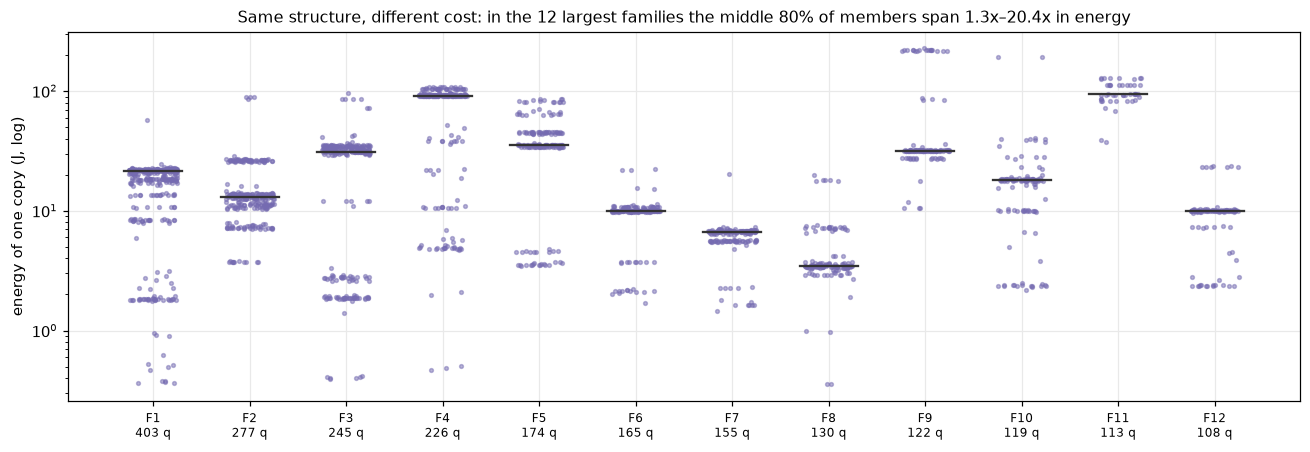

[17 s]  sg_family_members('F1') lists a family's queries with their features and energy


In [9]:
t0 = time.time()
SG_CANON_Q = SG.reset_index().groupby("canonical")["query"].min()          # canonical hash -> representative query
SG_REP = SG["canonical"].map(SG_CANON_Q)                                    # query -> representative
SG_U = np.sort(SG_CANON_Q.values)
SH_AST = {q: sg_shingles(SG_CAN[q]) for q in SG_U}
P_AST = minhash_pairs(SH_AST)

# energy of each query's single measured copy in the SQLStorm run (includes the ~0.5 J fixed cost of a batch)
sg_tm = pd.read_csv(SG_TIMING)
sg_tm = sg_tm[(sg_tm["phase"] == "measured") & (sg_tm["failed"] != 1) & (sg_tm["rapl_pkg_j"] > 0)].copy()
sg_tm["query"] = sg_tm["query"].str.extract(r"(\d+)\.sql$")[0].astype(int)
SG_E = sg_tm.drop_duplicates("query", keep="last").set_index("query")["rapl_pkg_j"]


def sg_features(t):
    outer = t if isinstance(t, exp.Select) else t.find(exp.Select)
    conds = [c for w in list(t.find_all(exp.Where)) + list(t.find_all(exp.Having)) for c in w.find_all(exp.Predicate)]
    return dict(
        limit=outer.args["limit"].sql() if outer is not None and outer.args.get("limit") else None,
        tables=tuple(sorted({x.name for x in t.find_all(exp.Table) if not re.fullmatch(r"cte\d+", x.name)})),
        joins=sum(1 for _ in t.find_all(exp.Join)),
        filters=tuple(sorted(f"{type(c).__name__}:{','.join(sorted(x.name for x in c.find_all(exp.Column)))}" for c in conds)),
        outputs=len(outer.expressions) if outer is not None else 0,
        select=tuple(sorted(e.unalias().sql() for e in outer.expressions)) if outer is not None else (),
        order=outer.args["order"].sql() if outer is not None and outer.args.get("order") else None,
        constants=tuple(sorted(l.sql() for l in t.find_all(exp.Literal) if l.find_ancestor(exp.Limit) is None)),
        ctes=sum(1 for _ in t.find_all(exp.CTE)), groups=sum(1 for _ in t.find_all(exp.Group)),
        windows=sum(1 for _ in t.find_all(exp.Window)), subqueries=sum(1 for _ in t.find_all(exp.Subquery)))


SG_FEAT = {q: sg_features(SG_CAN[q]) for q in SG_U}
SG_F = pd.DataFrame.from_dict(SG_FEAT, orient="index")

# structural families without chaining: the canonical query with the most similar neighbours becomes a centre
# and takes every still-unassigned neighbour; repeat. Every member is directly similar to its family's centre.
sg_nb = collections.defaultdict(set)
for a, b in zip(P_AST["a"], P_AST["b"]):
    sg_nb[a].add(b); sg_nb[b].add(a)
sg_centre = {}
for c in sorted(sg_nb, key=lambda q: (-len(sg_nb[q]), q)):
    if c in sg_centre:
        continue
    sg_free = [x for x in sg_nb[c] if x not in sg_centre]
    if sg_free:
        for x in [c] + sg_free:
            sg_centre[x] = c
SG_FAM = SG_REP.map(sg_centre)                                                  # query -> its family's centre
sg_size = SG_FAM.value_counts()
sg_order = sg_size.index                                                           # largest first
sg_famname = {f: f"F{i + 1}" for i, f in enumerate(sg_order)}
SG["family"] = SG_FAM.map(sg_famname)
SG_CENTRE = {sg_famname[f]: int(f) for f in sg_order}


def sg_describe(f):
    qs = SG_FAM.index[SG_FAM == f]
    reps = sorted(set(SG_REP[qs]))
    ft = SG_F.loc[reps]
    e = SG_E.reindex(qs).dropna()
    tables = collections.Counter(t for ts in ft["tables"] for t in ts)
    return {"family": sg_famname[f], "centre query": int(f), "queries": len(qs), "distinct SQL": len(reps),
            "tables (in ≥ half)": ", ".join(t for t, c in tables.most_common() if c >= len(reps) / 2),
            "joins": f"{ft['joins'].min()}–{ft['joins'].max()}",
            "LIMIT": f"{100 * ft['limit'].notna().mean():.0f}%", "CTE": f"{100 * (ft['ctes'] > 0).mean():.0f}%",
            "window": f"{100 * (ft['windows'] > 0).mean():.0f}%", "GROUP BY": f"{100 * (ft['groups'] > 0).mean():.0f}%",
            "energy median (J)": round(e.median(), 2) if len(e) else np.nan,
            "energy p10–p90 (J)": f"{e.quantile(0.1):.2f}–{e.quantile(0.9):.2f}" if len(e) else "",
            "p90 / p10": round(e.quantile(0.9) / e.quantile(0.1), 1) if len(e) > 2 else np.nan,
            "query numbers": f"{qs.min()}–{qs.max()}"}


SG_FAMS = pd.DataFrame([sg_describe(f) for f in sg_order]).set_index("family")
sg_cover = int(sg_size[sg_size > 1].sum())
SG_FAM_SUM = pd.DataFrame({"": ["structurally similar pairs (Jaccard ≥ 0.8)", "families (a centre and its similar queries)",
                                "queries in a family", "queries in the 10 largest families",
                                "families whose members span ≥ 3x in energy (p90/p10)"],
                           "value": [len(P_AST), len(sg_order), f"{sg_cover} of {len(SG)}",
                                     int(SG_FAMS['queries'].head(10).sum()),
                                     int((SG_FAMS['p90 / p10'] >= 3).sum())]}).set_index("")
display(SG_FAM_SUM)
display(SG_FAMS.head(12))

sg_top = SG_FAMS.head(12).index
fig, ax = plt.subplots(figsize=(12, 4.2))
for i, f in enumerate(sg_top):
    qs = SG.index[SG["family"] == f]
    e = SG_E.reindex(qs).dropna()
    ax.scatter(np.full(len(e), i) + np.random.default_rng(i).uniform(-0.25, 0.25, len(e)), e, s=6, alpha=0.5,
               color="#756bb1", zorder=3)
    ax.plot([i - 0.3, i + 0.3], [e.median()] * 2, color="#333", lw=1.5, zorder=4)
ax.set_yscale("log"); ax.set_xticks(range(len(sg_top)))
ax.set_xticklabels([f"{f}\n{SG_FAMS.at[f, 'queries']} q" for f in sg_top], fontsize=8)
ax.set_ylabel("energy of one copy (J, log)")
sg_spread = SG_FAMS.loc[sg_top, "p90 / p10"]
ax.set_title(f"Same structure, different cost: in the 12 largest families the middle 80% of members span "
             f"{sg_spread.min():.1f}x–{sg_spread.max():.1f}x in energy", fontsize=10.5)
fig.tight_layout(); savefig(fig, "sqlglot_families"); plt.show()
print(f"[{time.time() - t0:.0f} s]  sg_family_members('F1') lists a family's queries with their features and energy")


def sg_family_members(f):
    qs = SG.index[SG["family"] == f]
    out = SG_F.loc[SG_REP[qs].values].reset_index(drop=True)
    out.insert(0, "query", qs)
    out["energy_j"] = SG_E.reindex(qs).values
    return out.drop(columns=["filters"]).sort_values("energy_j")

#### What differs between structurally similar queries

For each similar pair, which of these changed between the two queries: the constant values (dates, names,
thresholds — LIMIT values aside), the outer LIMIT, the tables or number of joins, the WHERE/HAVING conditions
(operator and columns), the output columns (which or how many), the outer ORDER BY, or the count of CTEs, GROUP
BYs, windows and subqueries. "None of these" pairs differ elsewhere, e.g. in a join condition or GROUP BY list. The table then shows how far apart the
two queries' energies are for each kind of difference — over all pairs where it differs, and over the pairs
where it is the only difference. `sg_explain(q1, q2)` prints sqlglot's tree edit script for any pair.

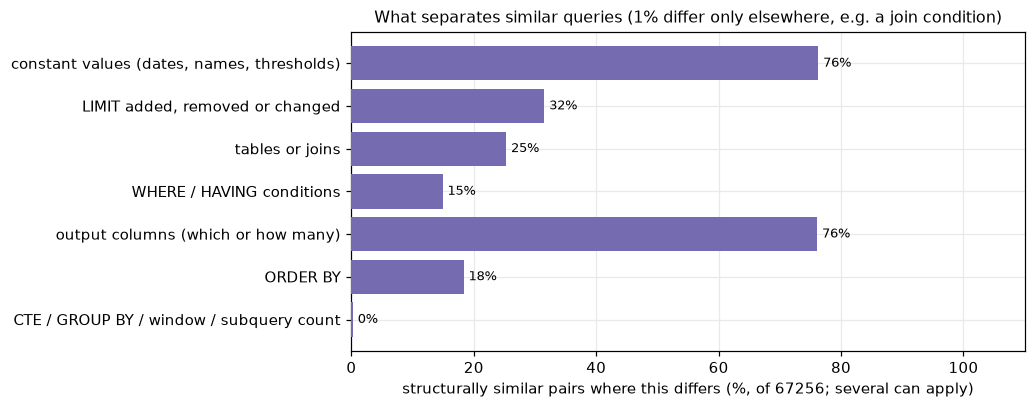

,pairs,median energy ratio,pairs ≥ 1.5x,pairs where it is the only difference,… median ratio,… ≥ 1.5x
difference,,,,,,
"constant values (dates, names, thresholds)",51300,1.38,49%,5709,1.20,45%
"LIMIT added, removed or changed",21195,1.21,39%,638,1.01,8%
tables or joins,17007,2.19,61%,379,1.27,44%
WHERE / HAVING conditions,10026,2.31,64%,101,1.02,22%
output columns (which or how many),51180,1.25,43%,4224,1.08,18%
ORDER BY,12342,1.15,37%,242,1.01,6%
CTE / GROUP BY / window / subquery count,161,1.85,55%,0,NaN,
none of these,647,1.01,8%,647,1.01,8%


largest energy gap where only the LIMIT differs (16.9x):
13741 -> 14911: 2 edits (Remove 2)
  Remove Literal      100
  Remove Limit        LIMIT 100


In [10]:
SG_CATS = [("constant values (dates, names, thresholds)", lambda a, b: SG_FEAT[a]["constants"] != SG_FEAT[b]["constants"]),
           ("LIMIT added, removed or changed", lambda a, b: SG_FEAT[a]["limit"] != SG_FEAT[b]["limit"]),
           ("tables or joins", lambda a, b: (SG_FEAT[a]["tables"], SG_FEAT[a]["joins"]) != (SG_FEAT[b]["tables"], SG_FEAT[b]["joins"])),
           ("WHERE / HAVING conditions", lambda a, b: SG_FEAT[a]["filters"] != SG_FEAT[b]["filters"]),
           ("output columns (which or how many)", lambda a, b: SG_FEAT[a]["select"] != SG_FEAT[b]["select"]),
           ("ORDER BY", lambda a, b: SG_FEAT[a]["order"] != SG_FEAT[b]["order"]),
           ("CTE / GROUP BY / window / subquery count",
            lambda a, b: any(SG_FEAT[a][k] != SG_FEAT[b][k] for k in ("ctes", "groups", "windows", "subqueries")))]
SG_LBL = [l for l, _ in SG_CATS]
SG_SIMP = P_AST.copy()
for lbl, f in SG_CATS:
    SG_SIMP[lbl] = [f(a, b) for a, b in zip(SG_SIMP["a"], SG_SIMP["b"])]
SG_CAT_SHARE = 100 * SG_SIMP[SG_LBL].mean()
SG_NONE_LISTED = 100 * (~SG_SIMP[SG_LBL].any(axis=1)).mean()

fig, ax = plt.subplots(figsize=(9.5, 3.8))
ax.barh(range(len(SG_CAT_SHARE)), SG_CAT_SHARE, color="#756bb1", zorder=3)
for i, v in enumerate(SG_CAT_SHARE):
    ax.text(v + 0.8, i, f"{v:.0f}%", va="center", fontsize=8.5)
ax.set_yticks(range(len(SG_CAT_SHARE))); ax.set_yticklabels(SG_CAT_SHARE.index); ax.invert_yaxis()
ax.set_xlim(0, 110); ax.set_xlabel(f"structurally similar pairs where this differs (%, of {len(SG_SIMP)}; several can apply)")
ax.set_title(f"What separates similar queries ({SG_NONE_LISTED:.0f}% differ only elsewhere, e.g. a join condition)",
             fontsize=10.5)
fig.tight_layout(); savefig(fig, "sqlglot_differences"); plt.show()

# how much each kind of difference changes the energy: ratio of the dearer to the cheaper query of a pair
sg_ea, sg_eb = SG_E.reindex(SG_SIMP["a"]).to_numpy(), SG_E.reindex(SG_SIMP["b"]).to_numpy()
SG_SIMP["ratio"] = np.maximum(sg_ea, sg_eb) / np.minimum(sg_ea, sg_eb)
sg_has_e = SG_SIMP["ratio"].notna()
sg_only = SG_SIMP[SG_LBL].sum(axis=1) == 1
sg_rows = []
for lbl in SG_LBL + ["none of these"]:
    m = (~SG_SIMP[SG_LBL].any(axis=1)) if lbl == "none of these" else SG_SIMP[lbl]
    m1 = m if lbl == "none of these" else (m & sg_only)
    sg_r, r1 = SG_SIMP.loc[m & sg_has_e, "ratio"], SG_SIMP.loc[m1 & sg_has_e, "ratio"]
    sg_rows.append({"difference": lbl, "pairs": int(m.sum()), "median energy ratio": round(sg_r.median(), 2),
                 "pairs ≥ 1.5x": f"{100 * (sg_r >= 1.5).mean():.0f}%",
                 "pairs where it is the only difference": int(m1.sum()),
                 "… median ratio": round(r1.median(), 2) if len(r1) else np.nan,
                 "… ≥ 1.5x": f"{100 * (r1 >= 1.5).mean():.0f}%" if len(r1) else ""})
SG_CAT_E = pd.DataFrame(sg_rows).set_index("difference")
display(SG_CAT_E)


def sg_explain(q1, q2, n=12):
    """sqlglot's tree edit script between two queries' canonical forms (inserts, removals, updates, moves)"""
    from sqlglot import diff
    ed = [e for e in diff(SG_CAN[SG_REP[q1]], SG_CAN[SG_REP[q2]], delta_only=True)]
    kinds = collections.Counter(type(e).__name__ for e in ed)
    print(f"{q1} -> {q2}: {len(ed)} edits ({', '.join(f'{k} {v}' for k, v in kinds.items())})")
    for e in ed[:n]:
        node = getattr(e, "expression", None) or getattr(e, "source", None)
        print(f"  {type(e).__name__:6s} {type(node).__name__:12s} {node.sql(dialect='postgres')[:90]}")


sg_r = SG_SIMP[SG_SIMP["LIMIT added, removed or changed"] & sg_only & sg_has_e].sort_values("ratio").tail(1)
if len(sg_r):
    print(f"largest energy gap where only the LIMIT differs ({sg_r['ratio'].iloc[0]:.1f}x):")
    sg_explain(int(sg_r["a"].iloc[0]), int(sg_r["b"].iloc[0]))

#### Export

Per query: canonical and template hashes, the other queries with the same canonical form, with the same template
but other constants, and the structurally similar queries (`;`-separated, copies included), their counts, the
closest structural match, the structural family, and the number of SQL statements in the file.

In [11]:
sg_members = SG.reset_index().groupby("canonical")["query"].apply(sorted)
sg_tmembers = SG.reset_index().groupby("template")["query"].apply(sorted)
sg_nbr = collections.defaultdict(set)
for a, b in zip(P_AST["a"], P_AST["b"]):
    sg_nbr[a].update(sg_members[SG.at[b, "canonical"]]); sg_nbr[b].update(sg_members[SG.at[a, "canonical"]])
sg_best = pd.concat([P_AST, P_AST.rename(columns={"a": "b", "b": "a"})]).sort_values("jaccard", ascending=False)
sg_best = sg_best.drop_duplicates("a").set_index("a")
SG_X = pd.DataFrame(index=SG.index)
SG_X["canonical_hash"], SG_X["template_hash"] = SG["canonical"], SG["template"]
SG_X["canonical_copies"] = [";".join(str(x) for x in sg_members[SG.at[q, "canonical"]] if x != q) or pd.NA for q in SG_X.index]
SG_X["same_template_queries"] = [";".join(str(x) for x in sg_tmembers[SG.at[q, "template"]]
                                       if SG.at[x, "canonical"] != SG.at[q, "canonical"]) or pd.NA for q in SG_X.index]
SG_X["structure_similar_queries"] = [";".join(map(str, sorted(sg_nbr[SG_REP[q]] - {q}))) or pd.NA for q in SG_X.index]
for c, n in [("canonical_copies", "canonical_copies_count"), ("same_template_queries", "same_template_count"),
             ("structure_similar_queries", "structure_similar_count")]:
    SG_X[n] = SG_X[c].str.count(";").add(1).astype("Int64")
SG_X["most_similar_structure"] = SG_REP.map(sg_best["b"]).astype("Int64")
SG_X["most_similar_structure_jaccard"] = SG_REP.map(sg_best["jaccard"]).round(3)
SG_X["structural_family"] = SG["family"]
SG_X["sql_statements"] = pd.Series({q: len(ts) for q, ts in SG_TREES.items()})
SG_X.to_csv(SG_CSV)
print(f"{SG_CSV}: {len(SG_X)} queries;  with canonical copies {int(SG_X['canonical_copies'].notna().sum())}, "
      f"same template {int(SG_X['same_template_queries'].notna().sum())}, structurally similar "
      f"{int(SG_X['structure_similar_queries'].notna().sum())}")

csv/sqlstorm_tpch_sqlglot.csv: 17036 queries;  with canonical copies 2906, same template 2847, structurally similar 6020


## 6. Outputs (not run yet)

When `make outputs DB_NAME=tpch_idx DIR=queries/tpch/SQLStorm` has run, this section will pull
`outputs/tpch_idx/` and add the **same output** relation, as in `sqlstorm_outputs.ipynb` §3b. Until then
it only reports whether output files are present.

In [12]:
OUT_DIR = Path("cache/outputs_cache/tpch_idx")
n_out = len(list(OUT_DIR.glob("*.txt"))) if OUT_DIR.exists() else 0
print(f"output files for tpch_idx in {OUT_DIR}: {n_out} — " +
      ("same-output comparison not available yet" if n_out == 0 else "ready to add the same-output relation"))

output files for tpch_idx in cache\outputs_cache\tpch_idx: 0 — same-output comparison not available yet
